In [4]:
!pip install -q pandas numpy scikit-learn imbalanced-learn matplotlib seaborn xgboost joblib


In [5]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [6]:
print("\n" + "="*70)
print("UPLOAD CREDIT CARD DATASET")
print("="*70)

print("Select your CSV dataset from your computer.")

uploaded = files.upload()

if not uploaded:
    raise ValueError("No file was uploaded.")

filename = list(uploaded.keys())[0]

print("\nUploaded file:", filename)


UPLOAD CREDIT CARD DATASET
Select your CSV dataset from your computer.


Saving credit_card_fraud_10k.csv to credit_card_fraud_10k.csv

Uploaded file: credit_card_fraud_10k.csv


In [7]:
df = pd.read_csv(filename)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())


Dataset loaded successfully!
Shape: (10000, 10)

First 5 rows:


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [8]:
print("\n" + "="*70)
print("DATA EXPLORATION")
print("="*70)

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")

missing = df.isnull().sum()

if missing.sum() == 0:
    print("No missing values.")
else:
    print(missing[missing > 0])


print("\nDuplicate Records:")
print(df.duplicated().sum())



DATA EXPLORATION

Dataset Shape:
(10000, 10)

Data Types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object

Missing Values:
No missing values.

Duplicate Records:
0


In [9]:
TARGET = "is_fraud"

if TARGET not in df.columns:

    raise ValueError(
        f"Target column '{TARGET}' was not found.\n"
        f"Available columns: {df.columns.tolist()}"
    )

print(f"\nTarget column '{TARGET}' found successfully.")


Target column 'is_fraud' found successfully.


In [10]:
print("\n" + "="*70)
print("ORIGINAL CLASS DISTRIBUTION")
print("="*70)

class_counts = df[TARGET].value_counts().sort_index()

legitimate = class_counts.get(0, 0)
fraud = class_counts.get(1, 0)

total = len(df)

print(f"Legitimate transactions : {legitimate:,}")
print(f"Fraudulent transactions  : {fraud:,}")

print(
    f"\nLegitimate percentage: "
    f"{legitimate / total * 100:.4f}%"
)

print(
    f"Fraud percentage: "
    f"{fraud / total * 100:.4f}%"
)




ORIGINAL CLASS DISTRIBUTION
Legitimate transactions : 9,849
Fraudulent transactions  : 151

Legitimate percentage: 98.4900%
Fraud percentage: 1.5100%


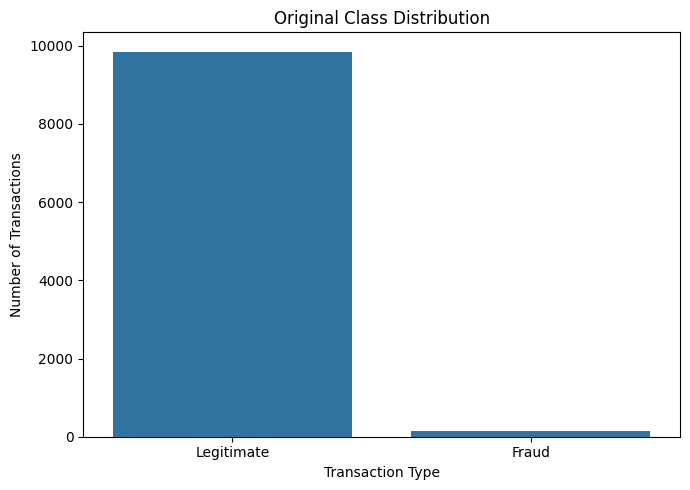

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET,
    order=[0, 1]
)

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.title("Original Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*70)
print("DATA CLEANING")
print("="*70)

df_cleaned = df.copy()

df_cleaned = df_cleaned.dropna(
    subset=[TARGET]
)

duplicates_before = df_cleaned.duplicated().sum()

df_cleaned = df_cleaned.drop_duplicates()

print(
    "Duplicates removed:",
    duplicates_before
)


numeric_columns = df_cleaned.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:

    if column != TARGET:

        df_cleaned[column] = (
            df_cleaned[column]
            .fillna(
                df_cleaned[column].median()
            )
        )

print(
    "Remaining missing values:",
    df_cleaned.isnull().sum().sum()
)

print(
    "Cleaned dataset shape:",
    df_cleaned.shape
)


DATA CLEANING
Duplicates removed: 0
Remaining missing values: 0
Cleaned dataset shape: (10000, 10)


In [13]:
cleaned_filename = "credit_card_fraud_cleaned.csv"

df_cleaned.to_csv(
    cleaned_filename,
    index=False
)

print(
    "\nCleaned dataset saved as:",
    cleaned_filename
)


Cleaned dataset saved as: credit_card_fraud_cleaned.csv


In [14]:
X = df_cleaned.drop(
    columns=[TARGET]
)

y = df_cleaned[TARGET]

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (10000, 9)
Target shape: (10000,)


In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
import pandas as pd
import numpy as np

non_numeric_cols = X.select_dtypes(exclude=np.number).columns.tolist()

if non_numeric_cols:
    print(f"Non-numeric columns detected: {non_numeric_cols}")

    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    preprocessor = make_column_transformer(
        (ohe, non_numeric_cols),
        remainder='passthrough'
    )

    X_encoded_array = preprocessor.fit_transform(X)
    new_column_names = preprocessor.get_feature_names_out()
    X = pd.DataFrame(X_encoded_array, columns=new_column_names, index=X.index)

    print("Categorical features one-hot encoded successfully.")
    print("Updated X shape:", X.shape)
else:
    print("\nAll features are numeric.")

Non-numeric columns detected: ['merchant_category']
Categorical features one-hot encoded successfully.
Updated X shape: (10000, 13)


In [16]:
print("\n" + "="*70)
print("TRAIN TEST SPLIT")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())


TRAIN TEST SPLIT
Training samples: 8000
Testing samples : 2000

Training distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [17]:
print("\n" + "="*70)
print("FEATURE SCALING")
print("="*70)

print(
    """
Random Forest and XGBoost are tree-based models.

Tree-based models generally do not require StandardScaler,
so scaling is intentionally skipped here.

This makes the implementation faster while avoiding
unnecessary preprocessing.

The original Time and Amount features are retained.
"""
)


FEATURE SCALING

Random Forest and XGBoost are tree-based models.

Tree-based models generally do not require StandardScaler,
so scaling is intentionally skipped here.

This makes the implementation faster while avoiding
unnecessary preprocessing.

The original Time and Amount features are retained.



In [18]:
print("\n" + "="*70)
print("SMOTE")
print("="*70)

print("BEFORE SMOTE:")
print(y_train.value_counts())

smote = SMOTE(
    sampling_strategy=0.20,
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAFTER SMOTE:")
print(
    pd.Series(y_train_smote).value_counts()
)

print(
    "\nOriginal training samples:",
    len(X_train)
)

print(
    "SMOTE training samples:",
    len(X_train_smote)
)




SMOTE
BEFORE SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

AFTER SMOTE:
is_fraud
0    7879
1    1575
Name: count, dtype: int64

Original training samples: 8000
SMOTE training samples: 9454


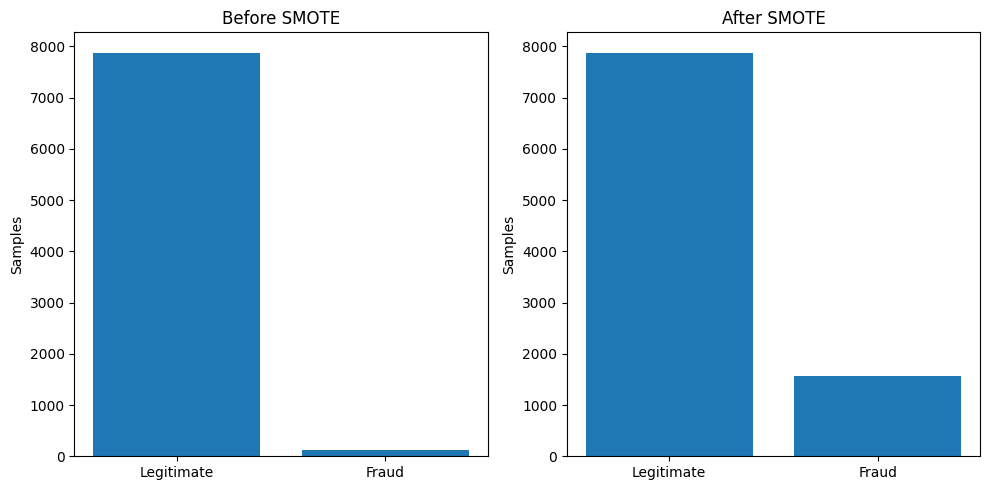

In [19]:
before = y_train.value_counts().sort_index()
after = pd.Series(
    y_train_smote
).value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.bar(
    ["Legitimate", "Fraud"],
    [
        before.get(0, 0),
        before.get(1, 0)
    ]
)

plt.title("Before SMOTE")
plt.ylabel("Samples")


plt.subplot(1, 2, 2)

plt.bar(
    ["Legitimate", "Fraud"],
    [
        after.get(0, 0),
        after.get(1, 0)
    ]
)

plt.title("After SMOTE")
plt.ylabel("Samples")

plt.tight_layout()
plt.show()


In [20]:
print("\n" + "="*70)
print("RANDOM FOREST TRAINING")
print("="*70)

rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=16,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training Random Forest...")
print(
    f"Training on {len(X_train_smote):,} samples..."
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print(
    "Random Forest training completed!"
)


RANDOM FOREST TRAINING
Training Random Forest...
Training on 9,454 samples...
Random Forest training completed!


In [21]:
print("\n" + "="*70)
print("XGBOOST TRAINING")
print("="*70)

xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="aucpr",

    tree_method="hist",

    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training XGBoost...")
print(
    f"Training on {len(X_train_smote):,} samples..."
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print(
    "XGBoost training completed!"
)



XGBOOST TRAINING
Training XGBoost...
Training on 9,454 samples...
XGBoost training completed!


In [22]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Legitimate",
                "Fraud"
            ],
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


In [23]:
rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)



Random Forest
Accuracy : 0.9975
Precision: 1.0000
Recall   : 0.8333
F1-score : 0.9091
ROC-AUC  : 0.9994
PR-AUC   : 0.9757

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1970
       Fraud       1.00      0.83      0.91        30

    accuracy                           1.00      2000
   macro avg       1.00      0.92      0.95      2000
weighted avg       1.00      1.00      1.00      2000



In [24]:
xgb_results = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)


XGBoost
Accuracy : 0.9985
Precision: 1.0000
Recall   : 0.9000
F1-score : 0.9474
ROC-AUC  : 0.9999
PR-AUC   : 0.9958

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1970
       Fraud       1.00      0.90      0.95        30

    accuracy                           1.00      2000
   macro avg       1.00      0.95      0.97      2000
weighted avg       1.00      1.00      1.00      2000




CONFUSION MATRICES


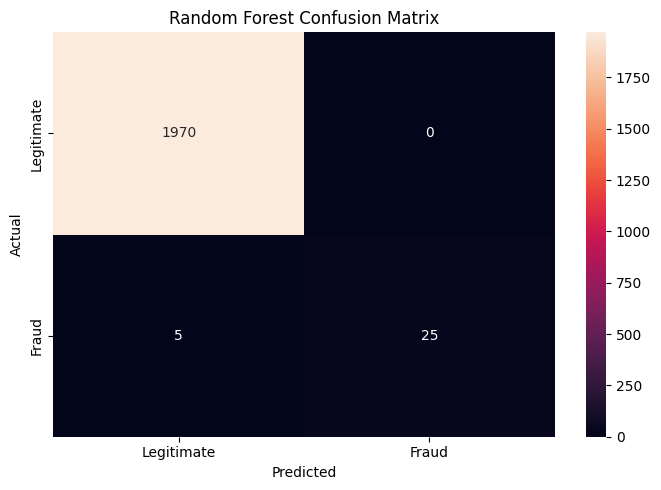

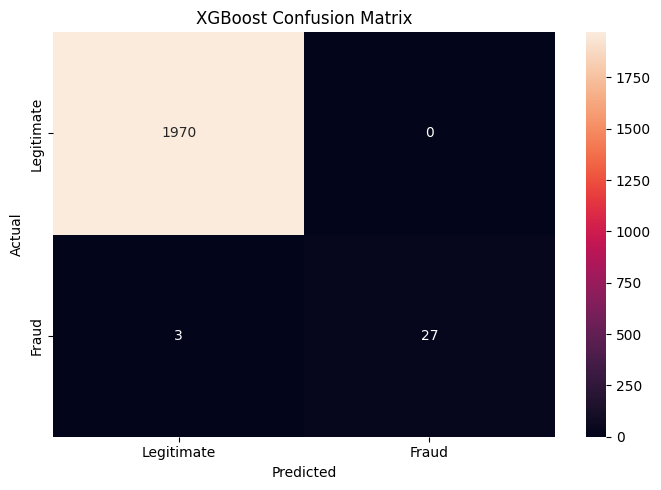

In [25]:
print("\n" + "="*70)
print("CONFUSION MATRICES")
print("="*70)

cm_rf = confusion_matrix(
    y_test,
    rf_results["y_pred"]
)

cm_xgb = confusion_matrix(
    y_test,
    xgb_results["y_pred"]
)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=[
        "Legitimate",
        "Fraud"
    ],
    yticklabels=[
        "Legitimate",
        "Fraud"
    ]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=[
        "Legitimate",
        "Fraud"
    ],
    yticklabels=[
        "Legitimate",
        "Fraud"
    ]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()



ROC CURVE


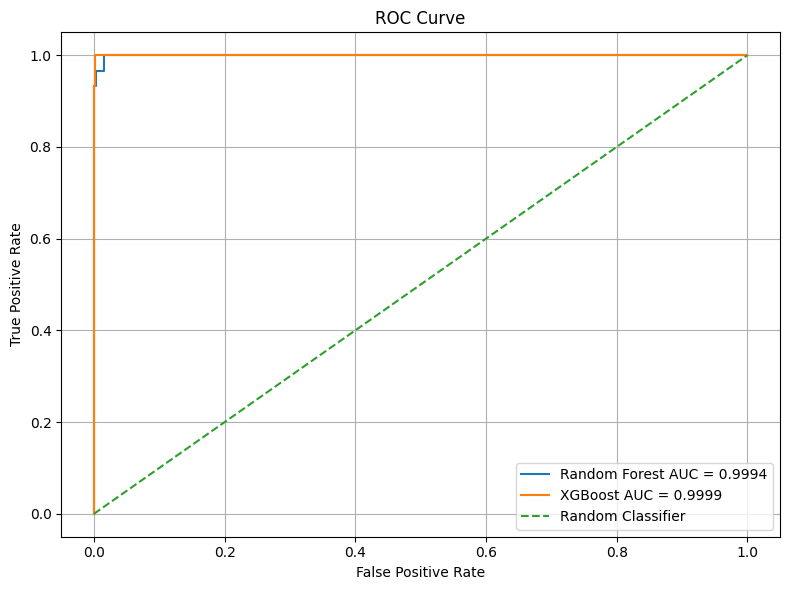

In [26]:
print("\n" + "="*70)
print("ROC CURVE")
print("="*70)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_results["y_prob"]
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    xgb_results["y_prob"]
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC = {rf_results['ROC-AUC']:.4f}"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost AUC = {xgb_results['ROC-AUC']:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



PRECISION-RECALL CURVE


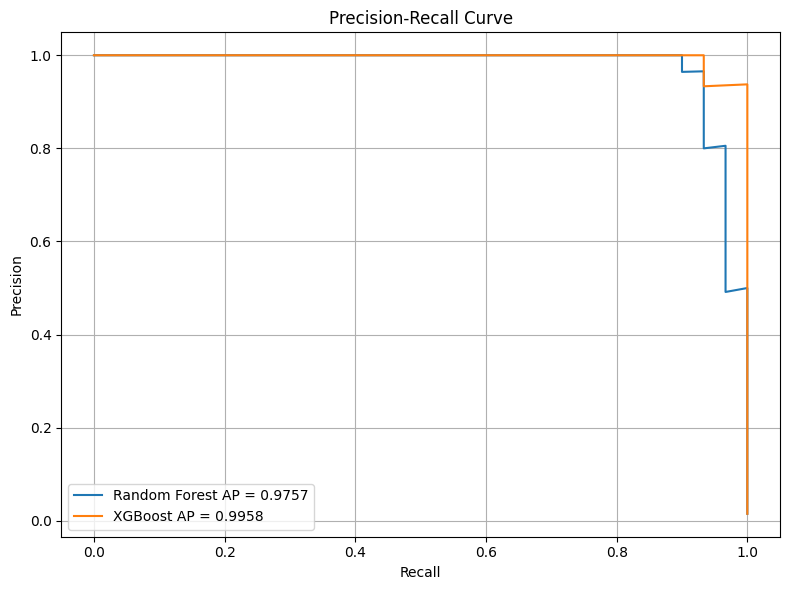

In [27]:
print("\n" + "="*70)
print("PRECISION-RECALL CURVE")
print("="*70)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_results["y_prob"]
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    xgb_results["y_prob"]
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest AP = {rf_results['PR-AUC']:.4f}"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost AP = {xgb_results['PR-AUC']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [28]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

comparison = pd.DataFrame([

    {
        "Model": "Random Forest",
        "Accuracy": rf_results["Accuracy"],
        "Precision": rf_results["Precision"],
        "Recall": rf_results["Recall"],
        "F1": rf_results["F1"],
        "ROC-AUC": rf_results["ROC-AUC"],
        "PR-AUC": rf_results["PR-AUC"]
    },

    {
        "Model": "XGBoost",
        "Accuracy": xgb_results["Accuracy"],
        "Precision": xgb_results["Precision"],
        "Recall": xgb_results["Recall"],
        "F1": xgb_results["F1"],
        "ROC-AUC": xgb_results["ROC-AUC"],
        "PR-AUC": xgb_results["PR-AUC"]
    }

])

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)

comparison.to_csv(
    "model_comparison.csv",
    index=False
)



MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.9975,1.0000,0.8333,0.9091,0.9994,0.9757
1,XGBoost,0.9985,1.0000,0.9000,0.9474,0.9999,0.9958


In [29]:
print("\n" + "="*70)
print("RANDOM FOREST TUNING")
print("="*70)

rf_pipeline = Pipeline([

    (
        "smote",
        SMOTE(
            sampling_strategy=0.20,
            random_state=42
        )
    ),

    (
        "classifier",
        RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_parameters = {

    "classifier__n_estimators": [
        50,
        80
    ],

    "classifier__max_depth": [
        12,
        16
    ],

    "classifier__min_samples_split": [
        2,
        5
    ],

    "classifier__min_samples_leaf": [
        1,
        2
    ]

}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_parameters,
    n_iter=3,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Random Forest tuning...")

rf_search.fit(
    X_train,
    y_train
)

print("\nBest Random Forest parameters:")
print(rf_search.best_params_)

print(
    "\nBest CV F1:",
    rf_search.best_score_
)




RANDOM FOREST TUNING
Starting Random Forest tuning...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best Random Forest parameters:
{'classifier__n_estimators': 80, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 12}

Best CV F1: 0.6769230769230771


In [30]:
tuned_rf_results = evaluate_model(
    rf_search.best_estimator_,
    X_test,
    y_test,
    "Tuned Random Forest"
)


Tuned Random Forest
Accuracy : 0.9955
Precision: 1.0000
Recall   : 0.7000
F1-score : 0.8235
ROC-AUC  : 0.9991
PR-AUC   : 0.9588

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1970
       Fraud       1.00      0.70      0.82        30

    accuracy                           1.00      2000
   macro avg       1.00      0.85      0.91      2000
weighted avg       1.00      1.00      1.00      2000



In [31]:
print("\n" + "="*70)
print("XGBOOST TUNING")
print("="*70)

xgb_pipeline = Pipeline([

    (
        "smote",
        SMOTE(
            sampling_strategy=0.20,
            random_state=42
        )
    ),

    (
        "classifier",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        )
    )
])

xgb_parameters = {

    "classifier__n_estimators": [
        80,
        120
    ],

    "classifier__max_depth": [
        3,
        5
    ],

    "classifier__learning_rate": [
        0.05,
        0.1
    ],

    "classifier__subsample": [
        0.8,
        1.0
    ]

}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_parameters,
    n_iter=3,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting XGBoost tuning...")

xgb_search.fit(
    X_train,
    y_train
)

print("\nBest XGBoost parameters:")
print(xgb_search.best_params_)

print(
    "\nBest CV F1:",
    xgb_search.best_score_
)




XGBOOST TUNING
Starting XGBoost tuning...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best XGBoost parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 80, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}

Best CV F1: 0.8459892371003482


In [32]:
tuned_xgb_results = evaluate_model(
    xgb_search.best_estimator_,
    X_test,
    y_test,
    "Tuned XGBoost"
)


Tuned XGBoost
Accuracy : 0.9970
Precision: 0.9286
Recall   : 0.8667
F1-score : 0.8966
ROC-AUC  : 0.9996
PR-AUC   : 0.9697

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1970
       Fraud       0.93      0.87      0.90        30

    accuracy                           1.00      2000
   macro avg       0.96      0.93      0.95      2000
weighted avg       1.00      1.00      1.00      2000



In [33]:
print("\n" + "="*70)
print("THRESHOLD TUNING")
print("="*70)

# Use tuned XGBoost as final candidate
final_model = xgb_search.best_estimator_

probabilities = final_model.predict_proba(
    X_test
)[:, 1]

thresholds = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision,

        "Recall": recall,

        "F1": f1

    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df.style.format({
        "Threshold": "{:.1f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)




THRESHOLD TUNING


,Threshold,Precision,Recall,F1
0,0.1,0.1546,1.0000,0.2679
1,0.2,0.4286,1.0000,0.6000
2,0.3,0.6522,1.0000,0.7895
3,0.4,0.8788,0.9667,0.9206
4,0.5,0.9286,0.8667,0.8966
5,0.6,0.9630,0.8667,0.9123
6,0.7,0.9474,0.6000,0.7347


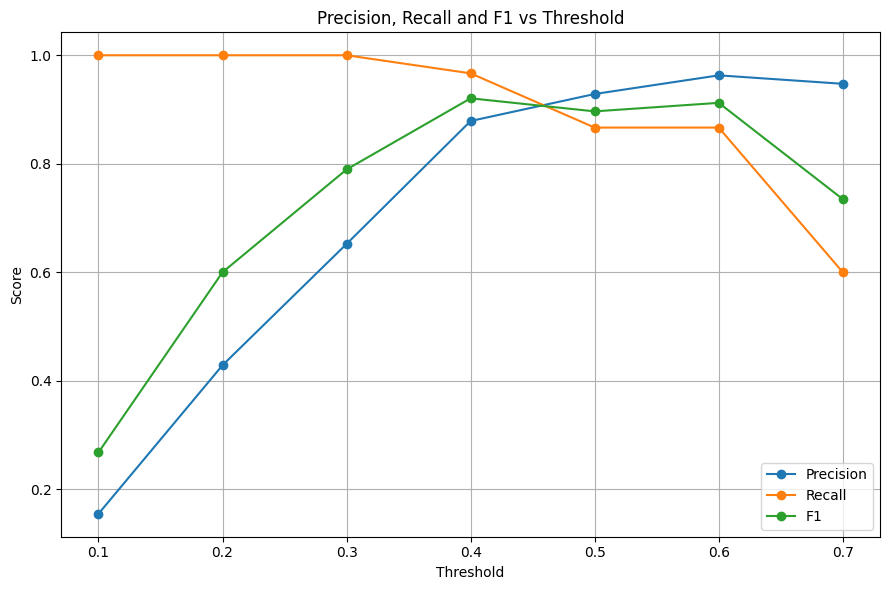

In [34]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 vs Threshold"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



In [35]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

BEST_THRESHOLD = float(
    best_row["Threshold"]
)

print("\n" + "="*70)
print("SELECTED THRESHOLD")
print("="*70)

print(
    f"Threshold: {BEST_THRESHOLD:.2f}"
)

print(
    f"Precision: {best_row['Precision']:.4f}"
)

print(
    f"Recall: {best_row['Recall']:.4f}"
)

print(
    f"F1-score: {best_row['F1']:.4f}"
)



SELECTED THRESHOLD
Threshold: 0.40
Precision: 0.8788
Recall: 0.9667
F1-score: 0.9206


In [36]:
final_predictions = (
    probabilities >= BEST_THRESHOLD
).astype(int)

print("\n" + "="*70)
print("FINAL FRAUD DETECTION RESULTS")
print("="*70)

print(
    f"Threshold : {BEST_THRESHOLD:.2f}"
)

print(
    f"Precision : "
    f"{precision_score(y_test, final_predictions, zero_division=0):.4f}"
)

print(
    f"Recall    : "
    f"{recall_score(y_test, final_predictions, zero_division=0):.4f}"
)

print(
    f"F1-score  : "
    f"{f1_score(y_test, final_predictions, zero_division=0):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)


FINAL FRAUD DETECTION RESULTS
Threshold : 0.40
Precision : 0.8788
Recall    : 0.9667
F1-score  : 0.9206

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1970
       Fraud       0.88      0.97      0.92        30

    accuracy                           1.00      2000
   macro avg       0.94      0.98      0.96      2000
weighted avg       1.00      1.00      1.00      2000



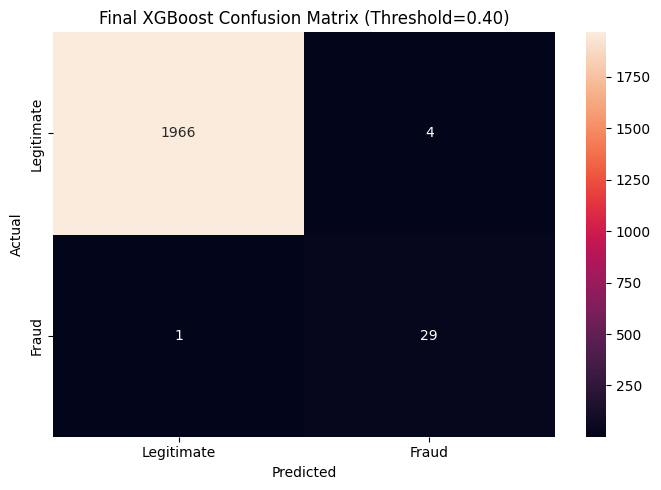

In [37]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Legitimate",
        "Fraud"
    ],
    yticklabels=[
        "Legitimate",
        "Fraud"
    ]
)

plt.title(
    f"Final XGBoost Confusion Matrix "
    f"(Threshold={BEST_THRESHOLD:.2f})"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


In [38]:
print("\n" + "="*70)
print("SAVING MODELS")
print("="*70)

joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

joblib.dump(
    xgb_model,
    "xgboost_model.pkl"
)

joblib.dump(
    rf_search.best_estimator_,
    "tuned_random_forest_pipeline.pkl"
)

joblib.dump(
    xgb_search.best_estimator_,
    "tuned_xgboost_pipeline.pkl"
)

print("Models saved successfully.")


SAVING MODELS
Models saved successfully.


In [39]:
threshold_df.to_csv(
    "threshold_analysis.csv",
    index=False
)

comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("\nResults saved:")
print("model_comparison.csv")
print("threshold_analysis.csv")
print("credit_card_fraud_cleaned.csv")



Results saved:
model_comparison.csv
threshold_analysis.csv
credit_card_fraud_cleaned.csv


In [40]:


import joblib
import os

final_model = xgb_search.best_estimator_

model_path = "/content/fraud_detection_model.pkl"

joblib.dump(final_model, model_path)

print("Final deployment model saved successfully!")
print("Location:", model_path)

Final deployment model saved successfully!
Location: /content/fraud_detection_model.pkl


In [42]:
from google.colab import files

files.download("/content/fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:


import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier



df_deploy = df_cleaned.copy()

TARGET = "is_fraud"

X_deploy = df_deploy.drop(columns=[TARGET])
y_deploy = df_deploy[TARGET]


categorical_features = X_deploy.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_deploy.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['merchant_category']

Numerical features:
['transaction_id', 'amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


In [44]:


preprocessor_deploy = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

deployment_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_deploy),
        ("smote", SMOTE(random_state=42)),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

print(" Deployment pipeline created successfully!")

 Deployment pipeline created successfully!


In [45]:

best_xgb_model = xgb_search.best_estimator_

tuned_xgb = best_xgb_model.named_steps["classifier"]

print("Tuned XGBoost parameters:")
print(tuned_xgb.get_params())

Tuned XGBoost parameters:
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'aucpr', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 80, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [46]:


tuned_classifier = XGBClassifier(
    objective="binary:logistic",
    learning_rate=0.05,
    max_depth=3,
    n_estimators=80,
    subsample=0.8,
    tree_method="hist",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

# Create the final deployment pipeline
deployment_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_deploy),
        ("smote", SMOTE(random_state=42)),
        ("classifier", tuned_classifier)
    ]
)

print("Deployment pipeline updated with tuned XGBoost parameters!")

Deployment pipeline updated with tuned XGBoost parameters!


In [47]:


print("Training final deployment pipeline...")

deployment_pipeline.fit(X_deploy, y_deploy)

print("Final deployment pipeline trained successfully!")

Training final deployment pipeline...
Final deployment pipeline trained successfully!


In [49]:

import joblib

deployment_model_path = "/content/fraud_detection_model.pkl"

joblib.dump(
    deployment_pipeline,
    deployment_model_path
)

print("Complete deployment model saved!")
print(deployment_model_path)

Complete deployment model saved!
/content/fraud_detection_model.pkl


In [50]:


import os

if os.path.exists(deployment_model_path):
    print("Model file exists!")
    print("Size:", os.path.getsize(deployment_model_path), "bytes")
else:
    print("Model file not found!")

Model file exists!
Size: 140679 bytes


In [51]:


import joblib

model_path = "/content/fraud_detection_model.pkl"

loaded_model = joblib.load(model_path)

print("Saved model loaded successfully!")
print("Model type:", type(loaded_model))

Saved model loaded successfully!
Model type: <class 'imblearn.pipeline.Pipeline'>


In [52]:


new_transaction = pd.DataFrame([{
    "transaction_id": 10001,
    "amount": 8500.00,
    "transaction_hour": 2,
    "merchant_category": "Travel",
    "foreign_transaction": 1,
    "location_mismatch": 1,
    "device_trust_score": 25,
    "velocity_last_24h": 8,
    "cardholder_age": 35
}])

print("New transaction:")
display(new_transaction)

New transaction:


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
0,10001,8500.0,2,Travel,1,1,25,8,35


In [53]:

fraud_probability = loaded_model.predict_proba(
    new_transaction
)[0][1]

threshold = 0.5

prediction = int(fraud_probability >= threshold)

print("========================================")
print("       FRAUD DETECTION RESULT")
print("========================================")

print(f"Fraud Probability: {fraud_probability:.2%}")

if prediction == 1:
    print("Prediction: FRAUD")
else:
    print("Prediction: LEGITIMATE")

print("========================================")

       FRAUD DETECTION RESULT
Fraud Probability: 97.83%
Prediction: FRAUD


In [54]:


normal_transaction = pd.DataFrame([{
    "transaction_id": 10002,
    "amount": 250.00,
    "transaction_hour": 14,
    "merchant_category": "Grocery",
    "foreign_transaction": 0,
    "location_mismatch": 0,
    "device_trust_score": 95,
    "velocity_last_24h": 1,
    "cardholder_age": 35
}])

fraud_probability = loaded_model.predict_proba(
    normal_transaction
)[0][1]

prediction = int(fraud_probability >= 0.5)

print("========================================")
print("       NORMAL TRANSACTION TEST")
print("========================================")

print(f"Fraud Probability: {fraud_probability:.2%}")

if prediction == 1:
    print("Prediction: FRAUD")
else:
    print("Prediction: LEGITIMATE")

print("========================================")

       NORMAL TRANSACTION TEST
Fraud Probability: 0.87%
Prediction: LEGITIMATE


In [55]:


import os

project_dir = "/content/credit-card-fraud-detector"

folders = [
    "models",
    "notebooks",
    "results",
    "src"
]

for folder in folders:
    os.makedirs(
        os.path.join(project_dir, folder),
        exist_ok=True
    )

print("Project folders created!")

print("\nProject location:")
print(project_dir)

Project folders created!

Project location:
/content/credit-card-fraud-detector


In [56]:


import shutil
import os

source_model = "/content/fraud_detection_model.pkl"

destination_model = (
    "/content/credit-card-fraud-detector/"
    "models/fraud_detection_model.pkl"
)

shutil.copy2(
    source_model,
    destination_model
)

print("Final model copied into project!")
print( destination_model)

Final model copied into project!
/content/credit-card-fraud-detector/models/fraud_detection_model.pkl


In [57]:


for root, dirs, files in os.walk(project_dir):

    level = root.replace(project_dir, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

credit-card-fraud-detector/
    results/
    models/
        fraud_detection_model.pkl
    notebooks/
    src/


In [58]:


requirements = """pandas
numpy
scikit-learn
imbalanced-learn
xgboost
joblib
flask
"""

requirements_path = "/content/credit-card-fraud-detector/requirements.txt"

with open(requirements_path, "w") as f:
    f.write(requirements)

print(" requirements.txt created!")

 requirements.txt created!


In [59]:
with open("/content/credit-card-fraud-detector/requirements.txt", "r") as f:
    print(f.read())

pandas
numpy
scikit-learn
imbalanced-learn
xgboost
joblib
flask



In [60]:


gitignore = """__pycache__/
*.pyc
.ipynb_checkpoints/

.env
*.log

venv/
.venv/

# Ignore datasets
data/
*.csv

# Ignore temporary files
*.tmp
"""

gitignore_path = "/content/credit-card-fraud-detector/.gitignore"

with open(gitignore_path, "w") as f:
    f.write(gitignore)

print(".gitignore created!")

.gitignore created!


In [61]:


for root, dirs, files in os.walk(project_dir):

    level = root.replace(project_dir, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

credit-card-fraud-detector/
    .gitignore
    requirements.txt
    results/
    models/
        fraud_detection_model.pkl
    notebooks/
    src/


In [62]:

predict_code = '''import joblib
import pandas as pd


MODEL_PATH = "models/fraud_detection_model.pkl"

# Load the trained deployment model
model = joblib.load(MODEL_PATH)


def predict_fraud(transaction):
    """
    Predict whether a transaction is fraudulent.

    Parameters:
        transaction (dict): Transaction details.

    Returns:
        dict: Fraud probability and prediction.
    """

    # Convert transaction dictionary to DataFrame
    data = pd.DataFrame([transaction])

    # Get fraud probability
    fraud_probability = model.predict_proba(data)[0][1]

    # Classification threshold
    threshold = 0.5

    # Final prediction
    prediction = int(fraud_probability >= threshold)

    return {
        "fraud_probability": float(fraud_probability),
        "is_fraud": prediction
    }


if __name__ == "__main__":

    # Example transaction
    transaction = {
        "transaction_id": 10001,
        "amount": 8500.00,
        "transaction_hour": 2,
        "merchant_category": "Travel",
        "foreign_transaction": 1,
        "location_mismatch": 1,
        "device_trust_score": 25,
        "velocity_last_24h": 8,
        "cardholder_age": 35
    }

    result = predict_fraud(transaction)

    print("Fraud Probability:",
          f"{result['fraud_probability']:.2%}")

    if result["is_fraud"] == 1:
        print("Prediction: FRAUD")
    else:
        print("Prediction: LEGITIMATE")
'''

predict_path = (
    "/content/credit-card-fraud-detector/"
    "src/predict.py"
)

with open(predict_path, "w") as f:
    f.write(predict_code)

print("predict.py created!")
print( predict_path)

predict.py created!
/content/credit-card-fraud-detector/src/predict.py


In [63]:

with open(
    "/content/credit-card-fraud-detector/src/predict.py",
    "r"
) as f:
    print(f.read())

import joblib
import pandas as pd


MODEL_PATH = "models/fraud_detection_model.pkl"

# Load the trained deployment model
model = joblib.load(MODEL_PATH)


def predict_fraud(transaction):
    """
    Predict whether a transaction is fraudulent.

    Parameters:
        transaction (dict): Transaction details.

    Returns:
        dict: Fraud probability and prediction.
    """

    # Convert transaction dictionary to DataFrame
    data = pd.DataFrame([transaction])

    # Get fraud probability
    fraud_probability = model.predict_proba(data)[0][1]

    # Classification threshold
    threshold = 0.5

    # Final prediction
    prediction = int(fraud_probability >= threshold)

    return {
        "fraud_probability": float(fraud_probability),
        "is_fraud": prediction
    }


if __name__ == "__main__":

    # Example transaction
    transaction = {
        "transaction_id": 10001,
        "amount": 8500.00,
        "transaction_hour": 2,
        "merchant_category": "Travel",
    

In [64]:

%cd /content/credit-card-fraud-detector

!python src/predict.py

/content/credit-card-fraud-detector
Fraud Probability: 97.83%
Prediction: FRAUD


In [66]:


readme = """# Credit Card Fraud Detection

## Project Overview

A machine learning based Credit Card Fraud Detection system that predicts whether a transaction is fraudulent or legitimate.

The project handles class imbalance using SMOTE and compares Random Forest and XGBoost models.

## Objectives

- Detect fraudulent credit card transactions.
- Handle class imbalance using SMOTE.
- Compare Random Forest and XGBoost.
- Perform hyperparameter tuning.
- Optimize the classification threshold.
- Evaluate models using classification metrics.
- Package the final model for reuse and deployment.

## Dataset Features

The dataset contains:

- transaction_id
- amount
- transaction_hour
- merchant_category
- foreign_transaction
- location_mismatch
- device_trust_score
- velocity_last_24h
- cardholder_age
- is_fraud

Target column:

`is_fraud`

## Machine Learning Workflow

Dataset
↓
Data Preprocessing
↓
Categorical Encoding
↓
Train/Test Split
↓
SMOTE
↓
Random Forest / XGBoost
↓
Hyperparameter Tuning
↓
Threshold Tuning
↓
Model Evaluation
↓
Model Packaging

## Models Used

### Random Forest

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees for classification.

### XGBoost

XGBoost is a gradient boosting algorithm used for classification and is used as the final model in this project.

## Handling Class Imbalance

SMOTE (Synthetic Minority Over-sampling Technique) is used to generate synthetic samples for the minority fraud class.

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC
- PR-AUC

## Final Model

The final deployment model is a tuned XGBoost pipeline.

The packaged model is stored as:

`models/fraud_detection_model.pkl`

## Project Structure

credit-card-fraud-detector/
│
├── models/
│   └── fraud_detection_model.pkl
│
├── notebooks/
│   └── EDPProject.ipynb
│
├── results/
│
├── src/
│   └── predict.py
│
├── .gitignore
├── requirements.txt
└── README.md

## Installation

Install the required dependencies:

pip install -r requirements.txt

## Prediction

The packaged model can be used through:

src/predict.py

Run:

python src/predict.py

## Model Packaging

The final trained pipeline is saved using Joblib.

The saved model can be loaded without retraining the machine learning model.

## Deployment Preparation

The project is prepared for deployment by:

- Packaging the final trained model.
- Separating prediction code from the training notebook.
- Providing requirements.txt.
- Providing .gitignore.
- Organizing the project into a GitHub-ready structure.
- Creating a reusable prediction script.

## Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Imbalanced-learn
- XGBoost
- Joblib

## Author
G. Yuva Sai -  24951A12C7
"""

readme_path = "/content/credit-card-fraud-detector/README.md"

with open(readme_path, "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [68]:
with open(
    "/content/credit-card-fraud-detector/README.md",
    "r"
) as f:
    print(f.read()[:1000])

# Credit Card Fraud Detection

## Project Overview

A machine learning based Credit Card Fraud Detection system that predicts whether a transaction is fraudulent or legitimate.

The project handles class imbalance using SMOTE and compares Random Forest and XGBoost models.

## Objectives

- Detect fraudulent credit card transactions.
- Handle class imbalance using SMOTE.
- Compare Random Forest and XGBoost.
- Perform hyperparameter tuning.
- Optimize the classification threshold.
- Evaluate models using classification metrics.
- Package the final model for reuse and deployment.

## Dataset Features

The dataset contains:

- transaction_id
- amount
- transaction_hour
- merchant_category
- foreign_transaction
- location_mismatch
- device_trust_score
- velocity_last_24h
- cardholder_age
- is_fraud

Target column:

`is_fraud`

## Machine Learning Workflow

Dataset
↓
Data Preprocessing
↓
Categorical Encoding
↓
Train/Test Split
↓
SMOTE
↓
Random Forest / XGBoost
↓
Hyperparameter Tuning
↓
Thres